# 02 — Behavioral and Temporal Analysis

**Project:** Transaction Intelligence: Customer Segmentation and Behavioral Analytics  
**Dataset:** Berka / PKDD'99 Financial Dataset  
**Course alignment:**

- **Week 2 — Exploratory Data Analysis and Visualization**
- **Week 6 — Time Series Analysis and Forecasting**
- **Week 7 — Recommendation Systems**

This notebook moves from portfolio-level exploration to account-level behavioral hypotheses. It creates segmentation-ready behavioral features, evaluates one aggregate monthly forecast, and mines service associations. It does **not** create customer segments, infer fraud, or claim that association rules are validated personalized recommendations.

## Notebook objectives

1. Describe transaction, balance, service, loan, card, district, and temporal patterns.
2. Construct one validated behavioral record for each account.
3. Analyze trend, seasonality, stationarity, and autocorrelation in monthly activity.
4. Compare naive and SARIMA forecasts using a chronological holdout.
5. Use Apriori to identify service-association hypotheses.
6. Produce three reproducible Gold-layer Parquet tables for later notebooks.

## 1. Analytical contract

The account remains the primary behavioral unit. Transaction-level summaries are used to understand events; account-level summaries prevent highly active accounts from dominating customer comparisons; monthly aggregates support organizational forecasting.

| Question | Unit | Method | Interpretation boundary |
|---|---|---|---|
| What activity is present? | Transaction and account | Descriptive statistics and visualization | Historical description only |
| How do account behaviors differ? | Account | Rates, ratios, balance profiles, service indicators | Hypotheses for segmentation |
| What monthly activity can be estimated? | Calendar month | Decomposition, diagnostics, naive forecast, SARIMA | Portfolio-level forecast demonstration |
| Which services co-occur? | Account-service basket | Apriori association rules | Recommendation hypotheses, not causal effects |

### Questions guiding the story

- Do accounts differ materially in transaction intensity and funding mix?
- Are some accounts predominantly cash-funded or salary-like-transfer-funded?
- Are account balance profiles and service breadth heterogeneous?
- Do withdrawal patterns vary by calendar month?
- Which observed service combinations occur more often than expected under independence?

## 2. Reproducible setup and Silver inputs

Notebook 1 created the validated Silver inputs used here. The local DuckDB database is accessed only for the standing-order purpose codes that are not present in the account Parquet table; ingestion and cleaning are not repeated.

In [1]:
from pathlib import Path
import platform
import warnings

import duckdb
import matplotlib.pyplot as plt
import mlxtend
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels
from IPython.display import display
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing pyproject.toml")


def sql_literal(path: Path) -> str:
    return "'" + str(path).replace("'", "''") + "'"


PROJECT_ROOT = find_project_root()
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DATABASE_PATH = INTERIM_DIR / "berka.duckdb"

TRANSACTIONS_PATH = INTERIM_DIR / "transactions_clean.parquet"
ACCOUNTS_CLIENTS_PATH = INTERIM_DIR / "accounts_clients.parquet"
LOANS_PATH = INTERIM_DIR / "loans_clean.parquet"
ACCOUNT_BASE_PATH = INTERIM_DIR / "account_analytical_base.parquet"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (11, 5.5), "axes.titleweight": "bold"})

environment = pd.Series(
    {
        "Python": platform.python_version(),
        "DuckDB": duckdb.__version__,
        "pandas": pd.__version__,
        "statsmodels": statsmodels.__version__,
        "mlxtend": mlxtend.__version__,
        "Project root": ".",
    },
    name="value",
)
display(environment.to_frame())

,value
Python,3.14.6
DuckDB,1.5.5
pandas,3.0.5
statsmodels,0.14.6
mlxtend,0.25.0
Project root,.


In [2]:
required_inputs = {
    "Local DuckDB database": DATABASE_PATH,
    "Clean transactions": TRANSACTIONS_PATH,
    "Account-client relationships": ACCOUNTS_CLIENTS_PATH,
    "Clean loans": LOANS_PATH,
    "Account analytical base": ACCOUNT_BASE_PATH,
}

input_status = pd.DataFrame(
    [
        {
            "input": name,
            "path": str(path.relative_to(PROJECT_ROOT)),
            "exists": path.is_file(),
            "size_mb": round(path.stat().st_size / 1_048_576, 3) if path.is_file() else None,
        }
        for name, path in required_inputs.items()
    ]
)
display(input_status)
assert input_status["exists"].all(), "Run Notebook 1 before this notebook."

connection = duckdb.connect(str(DATABASE_PATH), read_only=True)
transactions_scan = "read_parquet(" + sql_literal(TRANSACTIONS_PATH) + ")"
accounts_clients_scan = "read_parquet(" + sql_literal(ACCOUNTS_CLIENTS_PATH) + ")"
loans_scan = "read_parquet(" + sql_literal(LOANS_PATH) + ")"
account_base_scan = "read_parquet(" + sql_literal(ACCOUNT_BASE_PATH) + ")"

account_base = connection.execute("SELECT * FROM " + account_base_scan).fetchdf()
loans = connection.execute("SELECT * FROM " + loans_scan).fetchdf()

inventory = connection.execute(
    "SELECT 'transactions' AS dataset, COUNT(*) AS rows, COUNT(DISTINCT account_id) AS accounts FROM "
    + transactions_scan
    + " UNION ALL SELECT 'account base', COUNT(*), COUNT(DISTINCT account_id) FROM "
    + account_base_scan
    + " UNION ALL SELECT 'loans', COUNT(*), COUNT(DISTINCT account_id) FROM "
    + loans_scan
    + " UNION ALL SELECT 'account-client relationships', COUNT(*), COUNT(DISTINCT account_id) FROM "
    + accounts_clients_scan
).fetchdf()
display(inventory)

assert len(account_base) == account_base["account_id"].nunique() == 4_500
assert len(loans) == loans["loan_id"].nunique() == 682

,input,path,exists,size_mb
0,Local DuckDB database,data/interim/berka.duckdb,True,46.262
1,Clean transactions,data/interim/transactions_clean.parquet,True,7.636
2,Account-client relationships,data/interim/accounts_clients.parquet,True,0.065
3,Clean loans,data/interim/loans_clean.parquet,True,0.010
4,Account analytical base,data/interim/account_analytical_base.parquet,True,0.121


,dataset,rows,accounts
0,transactions,1056320,4500
1,account base,4500,4500
2,loans,682,682
3,account-client relationships,5369,4500


## 3. Week 2 — Exploratory Data Analysis and Visualization

The exploration proceeds from the full portfolio to account-level behavior. Numerical summaries use all observations. A deterministic subset is used only for dense transaction-distribution plots so that visualization remains responsive and reproducible.

In [3]:
transaction_summary = connection.execute(
    '''
    SELECT
        COUNT(*) AS transactions,
        COUNT(DISTINCT account_id) AS accounts,
        MIN(transaction_date) AS first_date,
        MAX(transaction_date) AS last_date,
        AVG(amount) AS mean_amount,
        MEDIAN(amount) AS median_amount,
        STDDEV_SAMP(amount) AS amount_std,
        QUANTILE_CONT(amount, 0.95) AS amount_p95,
        MAX(amount) AS maximum_amount,
        AVG(balance) AS transaction_weighted_mean_balance,
        MEDIAN(balance) AS transaction_weighted_median_balance,
        COUNT(*) FILTER (WHERE balance < 0) AS negative_balance_rows
    FROM '''
    + transactions_scan
).fetchdf()
display(transaction_summary.T.rename(columns={0: "value"}))

direction_profile = connection.execute(
    '''
    SELECT
        transaction_direction,
        COUNT(*) AS transaction_count,
        COUNT(DISTINCT account_id) AS account_count,
        SUM(amount) AS total_value,
        AVG(amount) AS mean_value,
        MEDIAN(amount) AS median_value
    FROM '''
    + transactions_scan
    + " GROUP BY 1 ORDER BY 1"
).fetchdf()
display(direction_profile)

,value
transactions,1056320
accounts,4500
first_date,1993-01-01 00:00:00
last_date,1998-12-31 00:00:00
mean_amount,5924.210653
median_amount,2100.0
amount_std,9522.698104
amount_p95,25700.0
maximum_amount,87400
transaction_weighted_mean_balance,38518.379134


,transaction_direction,transaction_count,account_count,total_value,mean_value,median_value
0,inflow,405083,4500,3.227483e+09,7967.460160,1600.0
1,outflow,651237,4500,3.030380e+09,4653.266834,2128.0


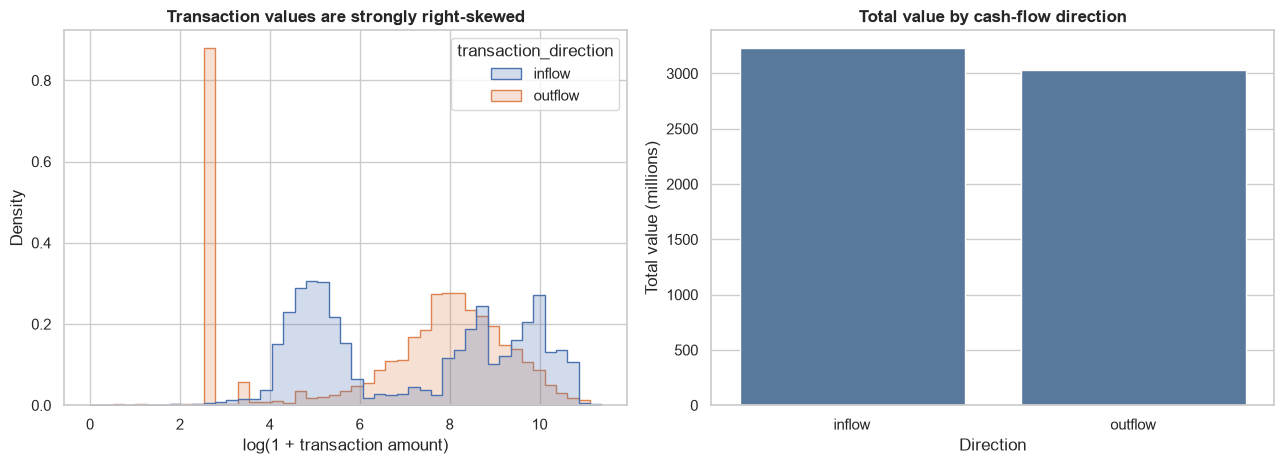

In [4]:
transaction_sample = connection.execute(
    '''
    SELECT transaction_direction, amount, balance
    FROM '''
    + transactions_scan
    + " WHERE trans_id % 10 = 0"
).fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.histplot(
    data=transaction_sample,
    x=np.log1p(transaction_sample["amount"]),
    hue="transaction_direction",
    element="step",
    stat="density",
    common_norm=False,
    bins=45,
    ax=axes[0],
)
axes[0].set(title="Transaction values are strongly right-skewed", xlabel="log(1 + transaction amount)")

direction_plot = direction_profile.assign(total_value_millions=lambda frame: frame["total_value"] / 1_000_000)
sns.barplot(data=direction_plot, x="transaction_direction", y="total_value_millions", ax=axes[1], color="#4C78A8")
axes[1].set(title="Total value by cash-flow direction", xlabel="Direction", ylabel="Total value (millions)")
fig.tight_layout()
plt.show()

,operation,transaction_count,account_count,total_value
0,cash_withdrawal,434918,4500,2.339571e+09
1,outgoing_transfer,208283,3602,6.726385e+08
2,not_recorded,183114,4453,2.747976e+07
3,cash_deposit,156743,4500,2.418523e+09
4,incoming_transfer,65226,1606,7.814800e+08
5,card_withdrawal,8036,807,1.817040e+07


,transaction_purpose,transaction_count,account_count,total_value
0,unspecified,535314,4500,5.482194e+09
1,interest_credit,183114,4453,2.747976e+07
2,statement_fee,155832,4396,2.744045e+06
3,household_payment,118065,3297,4.985064e+08
4,pension,30338,740,1.674721e+08
5,insurance,18500,510,2.417519e+07
6,loan_payment,13580,682,5.525300e+07
7,penalty_interest,1577,264,3.773600e+04


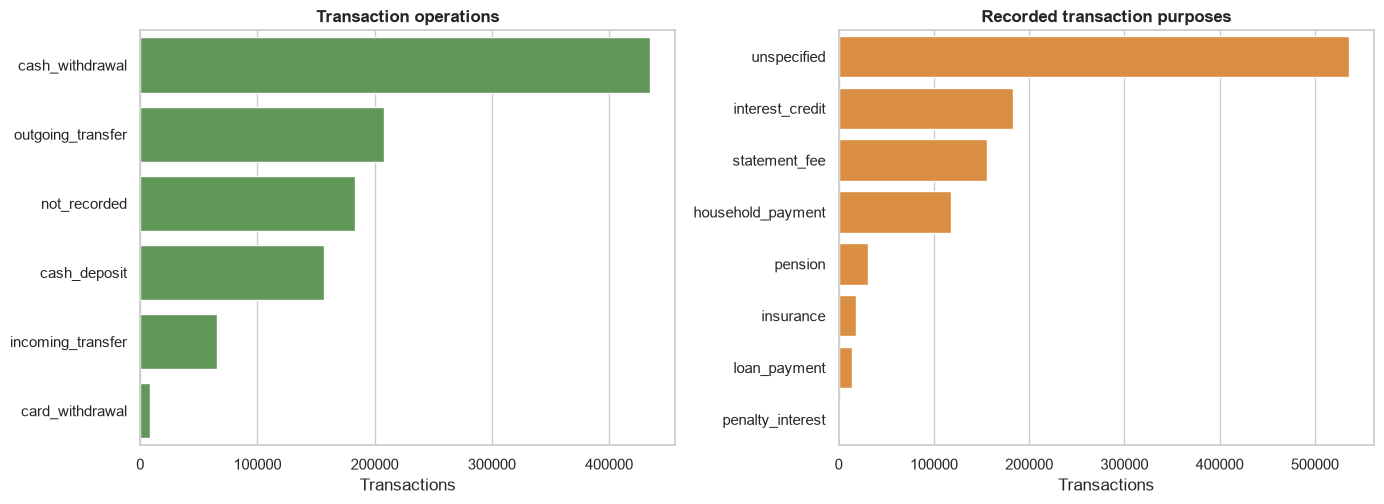

In [5]:
operation_profile = connection.execute(
    '''
    SELECT
        COALESCE(operation, 'not_recorded') AS operation,
        COUNT(*) AS transaction_count,
        COUNT(DISTINCT account_id) AS account_count,
        SUM(amount) AS total_value
    FROM '''
    + transactions_scan
    + " GROUP BY 1 ORDER BY transaction_count DESC"
).fetchdf()

purpose_profile = connection.execute(
    '''
    SELECT
        transaction_purpose,
        COUNT(*) AS transaction_count,
        COUNT(DISTINCT account_id) AS account_count,
        SUM(amount) AS total_value
    FROM '''
    + transactions_scan
    + " GROUP BY 1 ORDER BY transaction_count DESC"
).fetchdf()

display(operation_profile)
display(purpose_profile)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
sns.barplot(data=operation_profile, y="operation", x="transaction_count", ax=axes[0], color="#59A14F")
axes[0].set(title="Transaction operations", xlabel="Transactions", ylabel="")
sns.barplot(data=purpose_profile, y="transaction_purpose", x="transaction_count", ax=axes[1], color="#F28E2B")
axes[1].set(title="Recorded transaction purposes", xlabel="Transactions", ylabel="")
fig.tight_layout()
plt.show()

### Loan, card, and district context

Loan and card characteristics describe service adoption, not customer quality. District statistics are analyzed at one row per district; using one row per account would unintentionally weight districts by this bank's customer count.

,loan_status,loans,median_amount,median_duration
0,active_no_problems,403,153504.0,48.0
2,completed_no_problems,203,79632.0,24.0
1,active_with_problems,45,260400.0,48.0
3,completed_with_problems,31,96396.0,24.0


,card_type,cards
0,classic,659
1,junior,145
2,gold,88


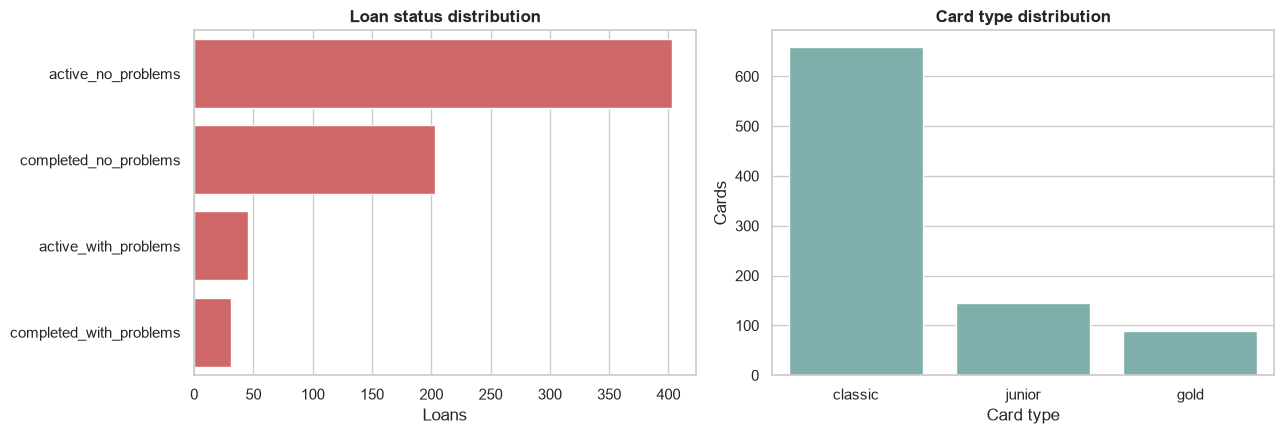

In [6]:
loan_profile = (
    loans.groupby("loan_status", dropna=False)
    .agg(loans=("loan_id", "size"), median_amount=("loan_amount", "median"), median_duration=("duration_months", "median"))
    .reset_index()
    .sort_values("loans", ascending=False)
)
card_profile = connection.execute(
    "SELECT type AS card_type, COUNT(*) AS cards FROM card GROUP BY 1 ORDER BY cards DESC"
).fetchdf()

display(loan_profile)
display(card_profile)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=loan_profile, y="loan_status", x="loans", ax=axes[0], color="#E15759")
axes[0].set(title="Loan status distribution", xlabel="Loans", ylabel="")
sns.barplot(data=card_profile, x="card_type", y="cards", ax=axes[1], color="#76B7B2")
axes[1].set(title="Card type distribution", xlabel="Card type", ylabel="Cards")
fig.tight_layout()
plt.show()

,count,mean,std,min,25%,50%,75%,max
district_inhabitants,77.0,133884.896104,136913.464909,42821.0,85852.0,108871.0,139012.0,1204953.0
district_urbanization_pct,77.0,63.035065,16.221727,33.9,51.9,59.8,73.5,100.0
district_average_salary,77.0,9031.675325,790.202347,8110.0,8512.0,8814.0,9317.0,12541.0
district_unemployment_1995,76.0,3.072368,1.664179,0.2,1.7,2.8,3.85,7.3
district_unemployment_1996,77.0,3.787013,1.90848,0.43,2.31,3.6,4.79,9.4
district_entrepreneurs_per_1000,77.0,116.12987,16.608773,81.0,105.0,113.0,126.0,167.0
district_crimes_1995,76.0,4850.315789,9888.951933,818.0,2029.75,2932.0,4525.5,85677.0
district_crimes_1996,77.0,5030.831169,11270.796786,888.0,2122.0,3040.0,4595.0,99107.0


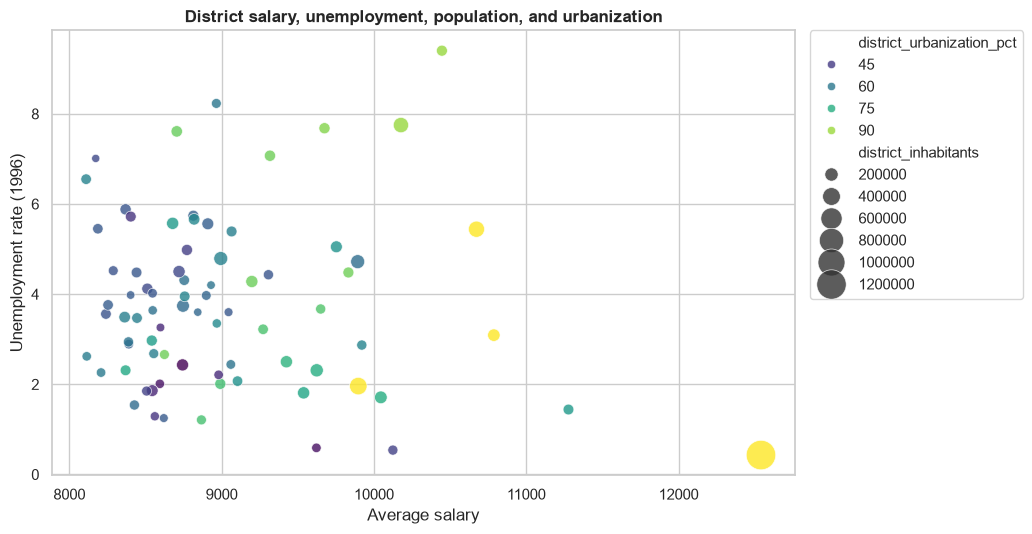

In [7]:
district_columns = [
    "account_district_id",
    "account_district_name",
    "district_inhabitants",
    "district_urbanization_pct",
    "district_average_salary",
    "district_unemployment_1995",
    "district_unemployment_1996",
    "district_entrepreneurs_per_1000",
    "district_crimes_1995",
    "district_crimes_1996",
]
districts = account_base[district_columns].drop_duplicates("account_district_id").reset_index(drop=True)
display(districts.drop(columns=["account_district_id", "account_district_name"]).describe().T)

district_plot = districts.dropna(subset=["district_average_salary", "district_unemployment_1996"])
fig, ax = plt.subplots(figsize=(10.5, 5.5))
sns.scatterplot(
    data=district_plot,
    x="district_average_salary",
    y="district_unemployment_1996",
    size="district_inhabitants",
    hue="district_urbanization_pct",
    sizes=(35, 450),
    palette="viridis",
    alpha=0.8,
    ax=ax,
)
ax.set(
    title="District salary, unemployment, population, and urbanization",
    xlabel="Average salary",
    ylabel="Unemployment rate (1996)",
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
fig.tight_layout()
plt.show()

### Temporal activity and resampling

Transactions are irregular events. Daily counts and values are first aggregated in DuckDB and then resampled to regular month-start intervals with pandas. Monthly distinct active-account counts are calculated separately because daily distinct counts cannot be summed without double-counting accounts.

In [8]:
daily_activity = connection.execute(
    '''
    SELECT
        transaction_date AS activity_date,
        COUNT(*) AS transaction_count,
        SUM(amount) FILTER (WHERE transaction_direction = 'inflow') AS total_inflow,
        SUM(amount) FILTER (WHERE transaction_direction = 'outflow') AS total_outflow,
        COUNT(*) FILTER (
            WHERE operation IN ('cash_withdrawal', 'card_withdrawal')
        ) AS withdrawal_count,
        SUM(amount) FILTER (
            WHERE operation IN ('cash_withdrawal', 'card_withdrawal')
        ) AS withdrawal_value
    FROM '''
    + transactions_scan
    + " GROUP BY 1 ORDER BY 1"
).fetchdf()

daily_activity["activity_date"] = pd.to_datetime(daily_activity["activity_date"])
monthly_activity = (
    daily_activity.set_index("activity_date")
    .resample("MS")
    .sum()
    .rename_axis("month")
    .reset_index()
)

monthly_accounts = connection.execute(
    '''
    SELECT
        DATE_TRUNC('month', transaction_date) AS month,
        COUNT(DISTINCT account_id) AS active_account_count
    FROM '''
    + transactions_scan
    + " GROUP BY 1 ORDER BY 1"
).fetchdf()
monthly_accounts["month"] = pd.to_datetime(monthly_accounts["month"])

monthly_activity = monthly_activity.merge(monthly_accounts, on="month", validate="one_to_one")
monthly_activity["net_cash_flow"] = monthly_activity["total_inflow"] - monthly_activity["total_outflow"]
monthly_activity["transactions_per_active_account"] = (
    monthly_activity["transaction_count"] / monthly_activity["active_account_count"]
)
monthly_activity["withdrawals_per_active_account"] = (
    monthly_activity["withdrawal_count"] / monthly_activity["active_account_count"]
)
monthly_activity["inflow_per_active_account"] = (
    monthly_activity["total_inflow"] / monthly_activity["active_account_count"]
)
monthly_activity["outflow_per_active_account"] = (
    monthly_activity["total_outflow"] / monthly_activity["active_account_count"]
)
monthly_activity["month_number"] = monthly_activity["month"].dt.month

expected_months = pd.date_range(monthly_activity["month"].min(), monthly_activity["month"].max(), freq="MS")
assert monthly_activity["month"].tolist() == expected_months.tolist()
assert len(monthly_activity) == 72
display(monthly_activity.head())

,month,transaction_count,total_inflow,total_outflow,withdrawal_count,withdrawal_value,active_account_count,net_cash_flow,transactions_per_active_account,withdrawals_per_active_account,inflow_per_active_account,outflow_per_active_account,month_number
0,1993-01-01,177,667459.0,34700.0,1,34700.0,96,632759.0,1.843750,0.010417,6952.697917,361.458333,1
1,1993-02-01,395,2445507.0,281427.0,22,271815.0,194,2164080.0,2.036082,0.113402,12605.706186,1450.654639,2
2,1993-03-01,676,3855641.0,874690.0,86,852494.0,298,2980951.0,2.268456,0.288591,12938.392617,2935.201342,3
3,1993-04-01,913,5325769.0,2052623.0,161,2026940.0,375,3273146.0,2.434667,0.429333,14202.050667,5473.661333,4
4,1993-05-01,1306,7664745.0,4016046.0,324,3897139.0,466,3648699.0,2.802575,0.695279,16447.950644,8618.124464,5


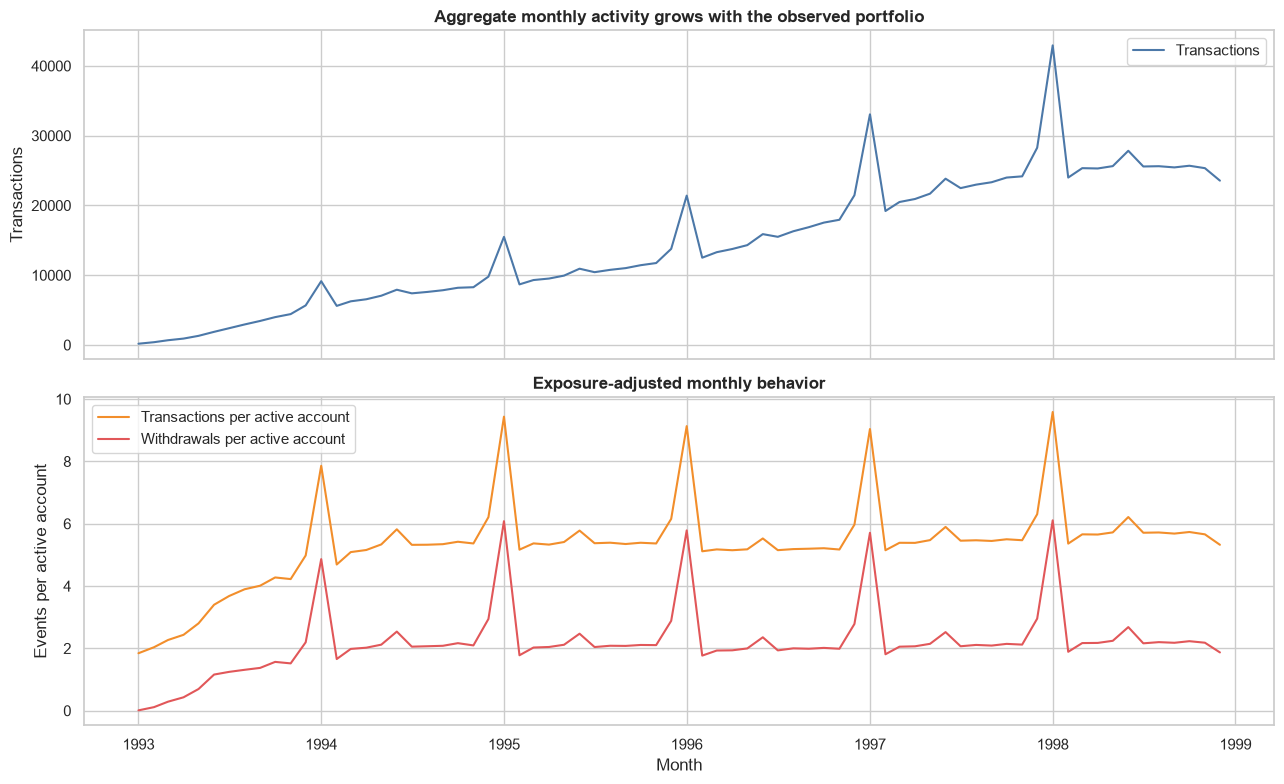

,month_number,mean_transactions_per_account,mean_withdrawals_per_account,mean_net_cash_flow
0,1,7.815282,4.759455,-1.530175e+07
1,2,4.586935,1.503019,1.120530e+07
2,3,4.824957,1.741863,5.325868e+06
3,4,4.851470,1.778805,4.444096e+06
4,5,4.987472,1.885816,2.836150e+06
5,6,5.439840,2.287833,-3.642036e+06
6,7,5.115416,1.917749,5.937728e+06
7,8,5.164515,1.962312,3.887138e+06
8,9,5.171804,1.965011,4.188178e+06
9,10,5.255783,2.038410,3.088171e+06


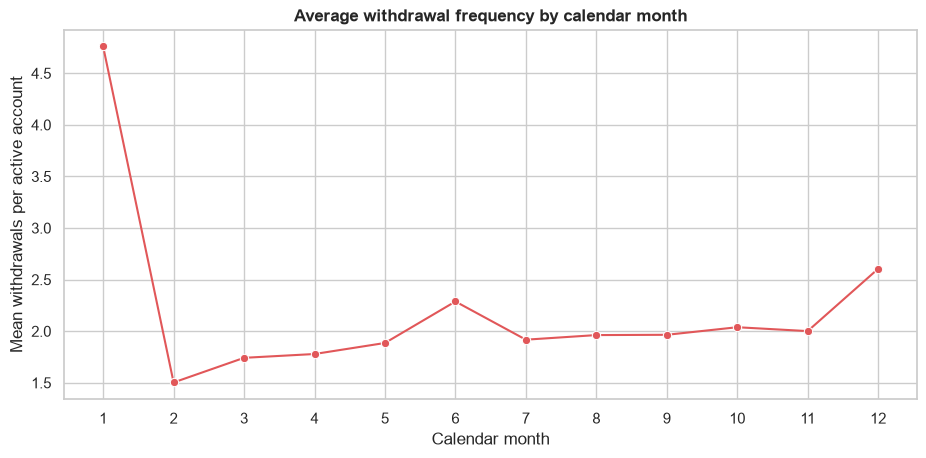

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(monthly_activity["month"], monthly_activity["transaction_count"], label="Transactions", color="#4C78A8")
axes[0].set(title="Aggregate monthly activity grows with the observed portfolio", ylabel="Transactions")
axes[0].legend()

axes[1].plot(
    monthly_activity["month"],
    monthly_activity["transactions_per_active_account"],
    label="Transactions per active account",
    color="#F28E2B",
)
axes[1].plot(
    monthly_activity["month"],
    monthly_activity["withdrawals_per_active_account"],
    label="Withdrawals per active account",
    color="#E15759",
)
axes[1].set(title="Exposure-adjusted monthly behavior", xlabel="Month", ylabel="Events per active account")
axes[1].legend()
fig.tight_layout()
plt.show()

month_of_year_profile = (
    monthly_activity.groupby("month_number")
    .agg(
        mean_transactions_per_account=("transactions_per_active_account", "mean"),
        mean_withdrawals_per_account=("withdrawals_per_active_account", "mean"),
        mean_net_cash_flow=("net_cash_flow", "mean"),
    )
    .reset_index()
)
display(month_of_year_profile)

fig, ax = plt.subplots(figsize=(11, 4.8))
sns.lineplot(
    data=month_of_year_profile,
    x="month_number",
    y="mean_withdrawals_per_account",
    marker="o",
    color="#E15759",
    ax=ax,
)
ax.set(
    title="Average withdrawal frequency by calendar month",
    xlabel="Calendar month",
    ylabel="Mean withdrawals per active account",
    xticks=range(1, 13),
)
plt.show()

## 4. Customer behavioral feature construction

Features use information available through the dataset end date. Rates normalize unequal account tenure; raw counts are retained for interpretation. Demographic attributes and loan outcomes are intentionally excluded from this behavioral feature table so they cannot silently drive clustering in Notebook 3.

### Key definitions

| Feature group | Definition |
|---|---|
| Transaction frequency | Transactions per observed month and per active month |
| Funding and spending | Mean/total inflow and outflow, their ratio, and channel shares |
| Balance behavior | Mean, median, standard deviation, minimum, maximum, latest, range, negative-balance share |
| Tenure and activity | Months from account opening to dataset end; active months divided by observed months |
| Transaction diversity | Distinct operations, purposes, and operation-purpose patterns |
| Service diversity | Count of observed card, loan, standing-order, recurring-income, pension, household, insurance, and leasing indicators |

### Salary-like deposit heuristic

Berka does not explicitly identify salary payments. `receives_salary_like_deposit` therefore means an **unlabeled incoming transfer** from the same counterparty observed in at least three months, with mean value at least 10,000 and coefficient of variation at most 0.25. It is an inferred recurring-income pattern, not a verified salary.

In [10]:
FEATURES_SQL = '''
WITH parameters AS (
    SELECT MAX(transaction_date) AS analysis_end_date
    FROM {transactions}
),
transaction_features AS (
    SELECT
        account_id,
        COUNT(*) AS transaction_count,
        COUNT(DISTINCT transaction_month) AS active_months,
        SUM(amount) FILTER (WHERE transaction_direction = 'inflow') AS total_inflow,
        AVG(amount) FILTER (WHERE transaction_direction = 'inflow') AS average_inflow,
        SUM(amount) FILTER (WHERE transaction_direction = 'outflow') AS total_outflow,
        AVG(amount) FILTER (WHERE transaction_direction = 'outflow') AS average_outflow,
        AVG(balance) AS average_balance,
        MEDIAN(balance) AS median_balance,
        STDDEV_SAMP(balance) AS balance_std,
        MIN(balance) AS minimum_balance,
        MAX(balance) AS maximum_balance,
        AVG((balance < 0)::INTEGER) AS negative_balance_share,
        COUNT(DISTINCT operation) AS operation_diversity,
        COUNT(DISTINCT transaction_purpose) FILTER (
            WHERE transaction_purpose <> 'unspecified'
        ) AS purpose_diversity,
        COUNT(DISTINCT COALESCE(operation, 'not_recorded') || ':' || transaction_purpose) AS transaction_diversity,
        AVG((operation = 'cash_deposit')::INTEGER) AS cash_deposit_share,
        AVG((operation IN ('cash_withdrawal', 'card_withdrawal'))::INTEGER) AS cash_withdrawal_share,
        AVG((operation = 'incoming_transfer')::INTEGER) AS incoming_transfer_share,
        MAX((transaction_purpose = 'pension')::INTEGER) > 0 AS receives_pension,
        MAX((transaction_purpose = 'household_payment')::INTEGER) > 0 AS has_household_transaction,
        MAX((transaction_purpose = 'insurance')::INTEGER) > 0 AS has_insurance_transaction
    FROM {transactions}
    GROUP BY account_id
),
latest_balance AS (
    SELECT account_id, balance AS latest_balance
    FROM {transactions}
    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY account_id ORDER BY transaction_date DESC, trans_id DESC
    ) = 1
),
recurring_income_sources AS (
    SELECT
        account_id,
        counterparty_bank,
        counterparty_account,
        COUNT(DISTINCT transaction_month) AS active_months,
        AVG(amount) AS mean_amount,
        STDDEV_POP(amount) / NULLIF(AVG(amount), 0) AS amount_cv
    FROM {transactions}
    WHERE transaction_direction = 'inflow'
      AND operation = 'incoming_transfer'
      AND transaction_purpose = 'unspecified'
      AND counterparty_account IS NOT NULL
    GROUP BY account_id, counterparty_bank, counterparty_account
),
salary_like_accounts AS (
    SELECT DISTINCT account_id
    FROM recurring_income_sources
    WHERE active_months >= 3
      AND mean_amount >= 10000
      AND amount_cv <= 0.25
),
order_features AS (
    SELECT
        account_id,
        MAX((TRIM(k_symbol) = 'SIPO')::INTEGER) > 0 AS has_household_order,
        MAX((TRIM(k_symbol) = 'POJISTNE')::INTEGER) > 0 AS has_insurance_order,
        MAX((TRIM(k_symbol) = 'LEASING')::INTEGER) > 0 AS makes_leasing_payments
    FROM "order"
    GROUP BY account_id
),
combined AS (
    SELECT
        base.account_id,
        DATE_DIFF('month', DATE_TRUNC('month', base.account_open_date), DATE_TRUNC('month', p.analysis_end_date)) + 1 AS observed_months,
        DATE_DIFF('day', base.account_open_date, p.analysis_end_date) / 30.4375 AS account_tenure_months,
        tf.* EXCLUDE (
            account_id,
            receives_pension,
            has_household_transaction,
            has_insurance_transaction
        ),
        lb.latest_balance,
        base.card_count,
        base.loan_count,
        base.standing_order_count,
        base.has_card,
        base.has_loan,
        base.has_standing_order,
        salary.account_id IS NOT NULL AS receives_salary_like_deposit,
        tf.receives_pension,
        tf.has_household_transaction OR COALESCE(of.has_household_order, FALSE) AS pays_household_expenses,
        tf.has_insurance_transaction OR COALESCE(of.has_insurance_order, FALSE) AS pays_insurance,
        COALESCE(of.makes_leasing_payments, FALSE) AS makes_leasing_payments
    FROM {account_base} AS base
    CROSS JOIN parameters AS p
    JOIN transaction_features AS tf USING (account_id)
    JOIN latest_balance AS lb USING (account_id)
    LEFT JOIN salary_like_accounts AS salary USING (account_id)
    LEFT JOIN order_features AS of USING (account_id)
)
SELECT
    account_id,
    observed_months,
    account_tenure_months,
    transaction_count,
    active_months,
    active_months::DOUBLE / observed_months AS active_month_ratio,
    transaction_count::DOUBLE / observed_months AS transactions_per_observed_month,
    transaction_count::DOUBLE / active_months AS transactions_per_active_month,
    total_inflow,
    average_inflow,
    total_outflow,
    average_outflow,
    total_inflow / NULLIF(total_outflow, 0) AS inflow_to_outflow_ratio,
    average_balance,
    median_balance,
    balance_std,
    minimum_balance,
    maximum_balance,
    latest_balance,
    maximum_balance - minimum_balance AS balance_range,
    negative_balance_share,
    operation_diversity,
    purpose_diversity,
    transaction_diversity,
    cash_deposit_share,
    cash_withdrawal_share,
    incoming_transfer_share,
    card_count,
    loan_count,
    standing_order_count,
    has_card,
    has_loan,
    has_standing_order,
    receives_salary_like_deposit,
    receives_pension,
    pays_household_expenses,
    pays_insurance,
    makes_leasing_payments,
    has_card::INTEGER
        + has_loan::INTEGER
        + has_standing_order::INTEGER
        + receives_salary_like_deposit::INTEGER
        + receives_pension::INTEGER
        + pays_household_expenses::INTEGER
        + pays_insurance::INTEGER
        + makes_leasing_payments::INTEGER AS service_diversity
FROM combined
ORDER BY account_id
'''.format(transactions=transactions_scan, account_base=account_base_scan)

customer_features = connection.execute(FEATURES_SQL).fetchdf()
display(customer_features.head())

,account_id,observed_months,account_tenure_months,transaction_count,active_months,active_month_ratio,transactions_per_observed_month,transactions_per_active_month,total_inflow,average_inflow,...,standing_order_count,has_card,has_loan,has_standing_order,receives_salary_like_deposit,receives_pension,pays_household_expenses,pays_insurance,makes_leasing_payments,service_diversity
0,1,46,45.273101,239,46,1.0,5.195652,5.195652,194322.0,1905.117647,...,1,False,False,True,False,False,True,False,False,2
1,2,71,70.110883,478,71,1.0,6.732394,6.732394,1597055.0,10506.940789,...,2,False,True,True,True,False,True,False,False,4
2,3,18,17.806982,117,18,1.0,6.500000,6.500000,173062.0,3762.217391,...,3,False,False,True,False,False,True,True,False,3
3,4,35,34.299795,186,35,1.0,5.314286,5.314286,192349.0,2959.215385,...,2,False,False,True,False,True,True,False,False,3
4,5,20,19.055441,84,20,1.0,4.200000,4.200000,97489.0,2785.400000,...,1,False,False,True,False,True,True,False,False,3


In [11]:
required_feature_columns = [
    "account_id",
    "transactions_per_observed_month",
    "average_inflow",
    "average_outflow",
    "inflow_to_outflow_ratio",
    "average_balance",
    "balance_std",
    "account_tenure_months",
    "active_month_ratio",
    "transaction_diversity",
    "service_diversity",
    "has_card",
    "has_loan",
    "has_standing_order",
]

feature_validation = pd.Series(
    {
        "rows": len(customer_features),
        "unique accounts": customer_features["account_id"].nunique(),
        "duplicate account IDs": customer_features["account_id"].duplicated().sum(),
        "missing required values": customer_features[required_feature_columns].isna().sum().sum(),
        "active-month ratio outside [0, 1]": (~customer_features["active_month_ratio"].between(0, 1)).sum(),
        "negative transaction frequencies": (customer_features["transactions_per_observed_month"] < 0).sum(),
    },
    name="value",
)
display(feature_validation.to_frame())

assert feature_validation["rows"] == feature_validation["unique accounts"] == 4_500
assert feature_validation["duplicate account IDs"] == 0
assert feature_validation["missing required values"] == 0
assert feature_validation["active-month ratio outside [0, 1]"] == 0
assert feature_validation["negative transaction frequencies"] == 0

behavior_summary_columns = [
    "transactions_per_observed_month",
    "average_inflow",
    "average_outflow",
    "inflow_to_outflow_ratio",
    "average_balance",
    "balance_std",
    "negative_balance_share",
    "transaction_diversity",
    "service_diversity",
]
display(customer_features[behavior_summary_columns].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T)

,value
rows,4500
unique accounts,4500
duplicate account IDs,0
missing required values,0
"active-month ratio outside [0, 1]",0
negative transaction frequencies,0


,count,mean,std,min,5%,25%,50%,75%,95%,max
transactions_per_observed_month,4500.0,5.556085,1.357805,0.310345,3.866667,4.772727,5.437060,6.282967,7.949169,11.466667
average_inflow,4500.0,7769.773444,5456.384171,851.385714,1721.061844,2952.035692,6599.089783,11688.899123,17615.053205,26885.953846
average_outflow,4500.0,4639.951985,3403.181162,498.735294,992.696180,1838.164096,3622.122500,6598.153603,11401.931190,19742.525000
inflow_to_outflow_ratio,4500.0,1.168193,0.644022,0.795939,1.017729,1.048451,1.089594,1.166473,1.436129,28.071429
average_balance,4500.0,36667.910906,15165.627811,5711.346154,16469.924821,23570.904108,34696.579426,47818.727179,64392.250290,81192.816993
balance_std,4500.0,12979.936540,7929.293890,1946.771770,3609.342332,6412.822830,11175.539654,17155.036902,28621.383107,37690.442560
negative_balance_share,4500.0,0.002885,0.019018,0.000000,0.000000,0.000000,0.000000,0.000000,0.007692,0.376900
transaction_diversity,4500.0,5.874444,1.197358,2.000000,4.000000,5.000000,6.000000,7.000000,8.000000,10.000000
service_diversity,4500.0,2.404000,1.149188,0.000000,0.000000,2.000000,3.000000,3.000000,4.000000,6.000000


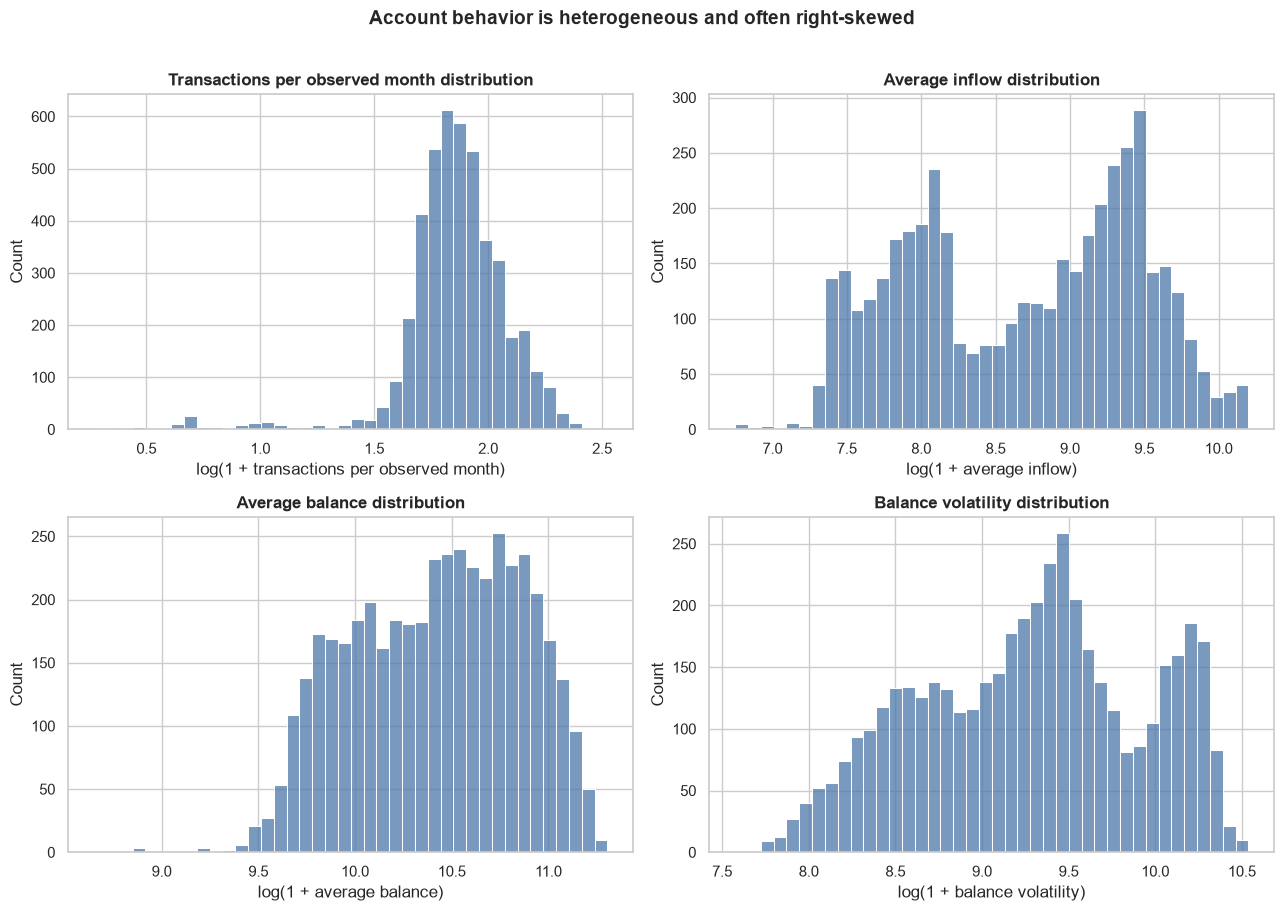

In [12]:
plot_features = [
    ("transactions_per_observed_month", "Transactions per observed month"),
    ("average_inflow", "Average inflow"),
    ("average_balance", "Average balance"),
    ("balance_std", "Balance volatility"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (column, label) in zip(axes.flat, plot_features):
    values = customer_features[column]
    if values.min() >= 0:
        sns.histplot(np.log1p(values), bins=40, ax=ax, color="#4C78A8")
        ax.set_xlabel("log(1 + " + label.lower() + ")")
    else:
        sns.histplot(values, bins=40, ax=ax, color="#4C78A8")
        ax.set_xlabel(label)
    ax.set_title(label + " distribution")
fig.suptitle("Account behavior is heterogeneous and often right-skewed", y=1.01, fontsize=14, weight="bold")
fig.tight_layout()
plt.show()

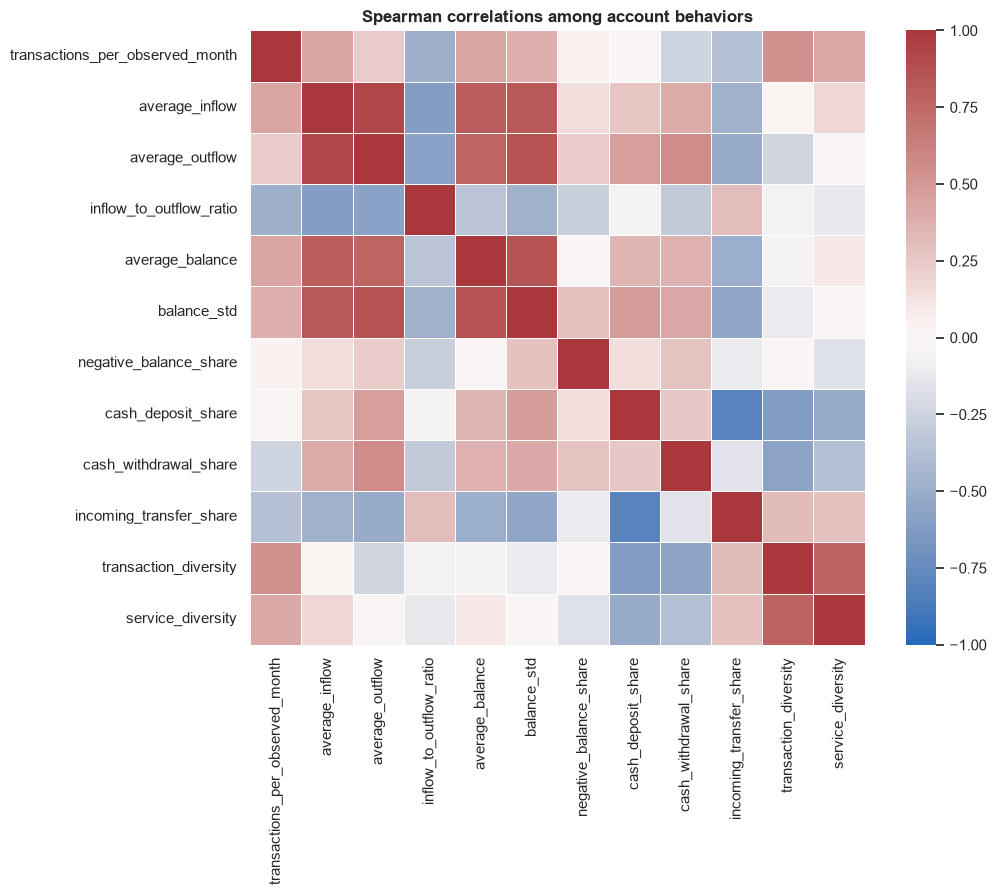

,feature_a,feature_b,spearman_rho,abs_rho
14,average_inflow,average_outflow,0.928279,0.928279
53,average_balance,balance_std,0.858687,0.858687
29,average_outflow,balance_std,0.858659,0.858659
17,average_inflow,balance_std,0.831461,0.831461
16,average_inflow,average_balance,0.807475,0.807475
93,cash_deposit_share,incoming_transfer_share,-0.807439,0.807439
131,transaction_diversity,service_diversity,0.776768,0.776768
28,average_outflow,average_balance,0.769096,0.769096
94,cash_deposit_share,transaction_diversity,-0.610223,0.610223
15,average_inflow,inflow_to_outflow_ratio,-0.609824,0.609824


In [13]:
correlation_features = [
    "transactions_per_observed_month",
    "average_inflow",
    "average_outflow",
    "inflow_to_outflow_ratio",
    "average_balance",
    "balance_std",
    "negative_balance_share",
    "cash_deposit_share",
    "cash_withdrawal_share",
    "incoming_transfer_share",
    "transaction_diversity",
    "service_diversity",
]
spearman_correlation = customer_features[correlation_features].corr(method="spearman")

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    spearman_correlation,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.4,
    ax=ax,
)
ax.set_title("Spearman correlations among account behaviors")
fig.tight_layout()
plt.show()

upper_triangle = spearman_correlation.where(
    np.triu(np.ones(spearman_correlation.shape, dtype=bool), k=1)
)
strongest_pairs = (
    upper_triangle.stack()
    .rename("spearman_rho")
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
    .assign(abs_rho=lambda frame: frame["spearman_rho"].abs())
    .sort_values("abs_rho", ascending=False)
    .head(12)
)
display(strongest_pairs)

In [14]:
funding_comparison = (
    customer_features.groupby("receives_salary_like_deposit")
    .agg(
        accounts=("account_id", "size"),
        median_average_inflow=("average_inflow", "median"),
        median_cash_deposit_share=("cash_deposit_share", "median"),
        median_incoming_transfer_share=("incoming_transfer_share", "median"),
        median_average_balance=("average_balance", "median"),
    )
    .reset_index()
)
display(funding_comparison)

behavioral_hypotheses = pd.DataFrame(
    [
        {
            "hypothesis": "Activity intensity may separate accounts.",
            "evidence to carry forward": "Wide account-level frequency distribution after tenure normalization.",
            "Notebook 3 implication": "Prefer rate features over raw lifetime transaction counts.",
        },
        {
            "hypothesis": "Funding channel may distinguish behavioral groups.",
            "evidence to carry forward": "Cash-deposit and incoming-transfer shares vary across accounts.",
            "Notebook 3 implication": "Compare channel shares and the salary-like indicator.",
        },
        {
            "hypothesis": "Liquidity level and volatility may form distinct profiles.",
            "evidence to carry forward": "Balance level, range, volatility, and negative-balance exposure differ.",
            "Notebook 3 implication": "Use robust transformations and avoid equating low balance with misconduct.",
        },
        {
            "hypothesis": "Service breadth may accompany behavioral complexity.",
            "evidence to carry forward": "Accounts vary in both transaction-pattern and service diversity.",
            "Notebook 3 implication": "Test whether service indicators improve interpretable clusters.",
        },
    ]
)
display(behavioral_hypotheses)

,receives_salary_like_deposit,accounts,median_average_inflow,median_cash_deposit_share,median_incoming_transfer_share,median_average_balance
0,False,4071,5694.364865,0.230769,0.000000,33693.442623
1,True,429,14542.740741,0.020173,0.197183,45743.129380


,hypothesis,evidence to carry forward,Notebook 3 implication
0,Activity intensity may separate accounts.,Wide account-level frequency distribution afte...,Prefer rate features over raw lifetime transac...
1,Funding channel may distinguish behavioral gro...,Cash-deposit and incoming-transfer shares vary...,Compare channel shares and the salary-like ind...
2,Liquidity level and volatility may form distin...,"Balance level, range, volatility, and negative...",Use robust transformations and avoid equating ...
3,Service breadth may accompany behavioral compl...,Accounts vary in both transaction-pattern and ...,Test whether service indicators improve interp...


## 5. Week 6 — Time Series Analysis and Forecasting

The primary series is monthly transaction count: an organizational workload measure with 72 equally spaced observations. Aggregate counts are affected by both customer behavior and the rapid expansion of observed accounts through 1997. Exposure-adjusted series are shown for diagnosis, but the forecast exercise remains at the requested organizational level.

An additive seasonal period of 12 months is used. The final 12 months form an untouched chronological test set; no random split is appropriate for ordered observations.

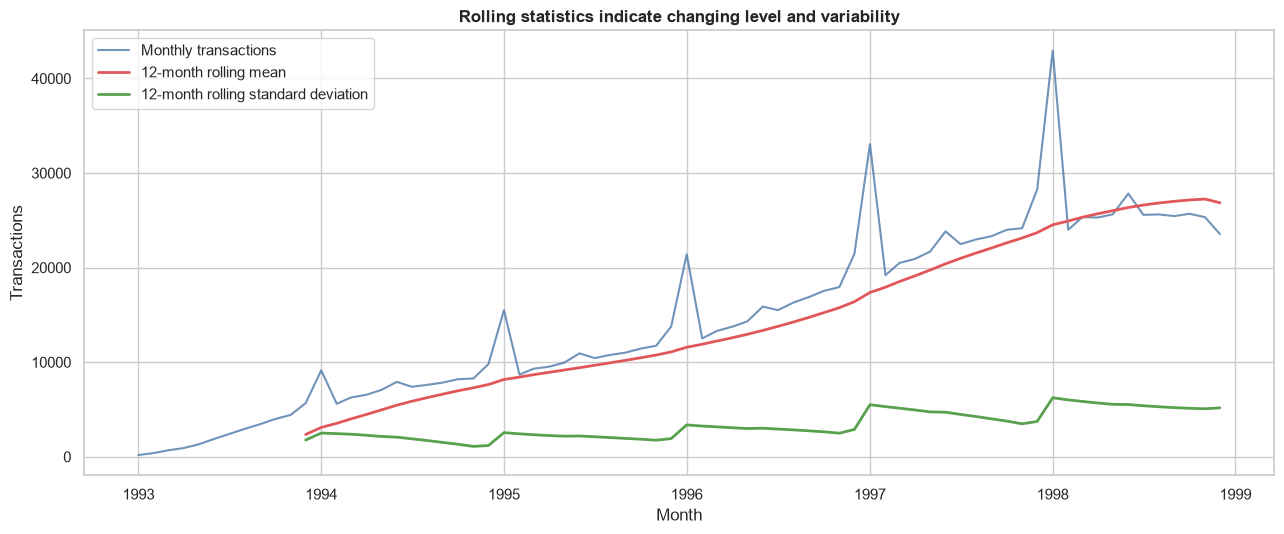

In [15]:
activity_series = monthly_activity.set_index("month")["transaction_count"].astype(float).asfreq("MS")
rolling_mean = activity_series.rolling(window=12).mean()
rolling_std = activity_series.rolling(window=12).std()

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(activity_series, label="Monthly transactions", color="#4C78A8", alpha=0.8)
ax.plot(rolling_mean, label="12-month rolling mean", color="#E15759", linewidth=2)
ax.plot(rolling_std, label="12-month rolling standard deviation", color="#59A14F", linewidth=2)
ax.set(title="Rolling statistics indicate changing level and variability", xlabel="Month", ylabel="Transactions")
ax.legend()
fig.tight_layout()
plt.show()

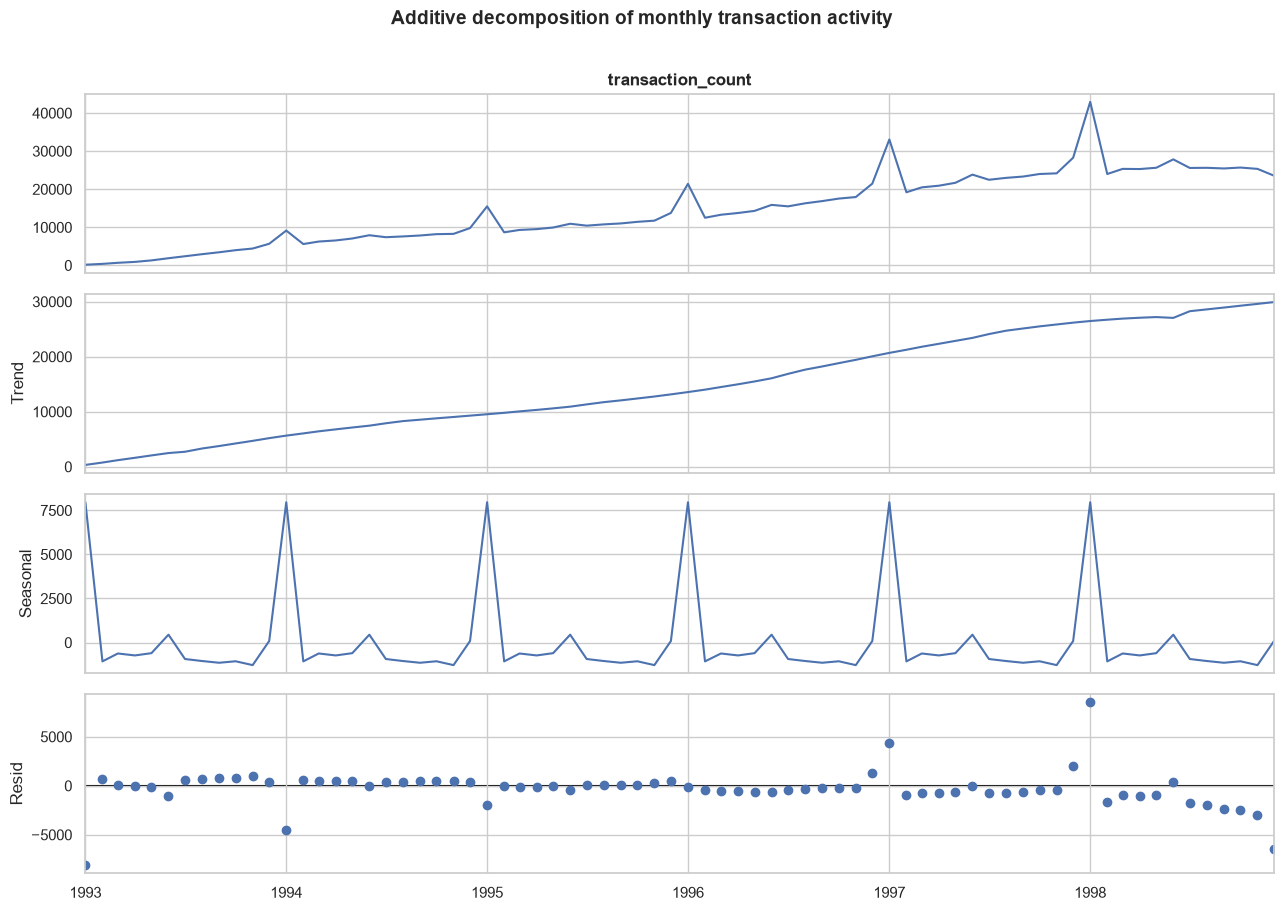

In [16]:
decomposition = seasonal_decompose(activity_series, model="additive", period=12, extrapolate_trend="freq")
decomposition_figure = decomposition.plot()
decomposition_figure.set_size_inches(13, 9)
decomposition_figure.suptitle("Additive decomposition of monthly transaction activity", y=1.01, fontsize=14, weight="bold")
decomposition_figure.tight_layout()
plt.show()

In [17]:
def adf_result(series: pd.Series, label: str) -> dict[str, float | str | int]:
    statistic, p_value, used_lags, observations, critical_values, _ = adfuller(series.dropna(), autolag="AIC")
    return {
        "series": label,
        "ADF statistic": statistic,
        "p_value": p_value,
        "used_lags": used_lags,
        "observations": observations,
        "critical_value_5pct": critical_values["5%"],
        "decision_at_0.05": "reject non-stationarity" if p_value <= 0.05 else "fail to reject non-stationarity",
    }


first_difference = activity_series.diff()
seasonal_first_difference = activity_series.diff(12).diff()
stationarity_results = pd.DataFrame(
    [
        adf_result(activity_series, "original monthly count"),
        adf_result(first_difference, "first difference"),
        adf_result(seasonal_first_difference, "seasonal + first difference"),
    ]
)
display(stationarity_results)

if (stationarity_results["p_value"] > 0.05).all():
    print(
        "The ADF test does not reject non-stationarity for any displayed transformation. "
        "Forecast results therefore require additional caution and holdout comparison."
    )

,series,ADF statistic,p_value,used_lags,observations,critical_value_5pct,decision_at_0.05
0,original monthly count,-1.307337,0.625809,12,59,-2.911939,fail to reject non-stationarity
1,first difference,0.110498,0.966771,11,59,-2.911939,fail to reject non-stationarity
2,seasonal + first difference,0.841653,0.992280,11,47,-2.925338,fail to reject non-stationarity


The ADF test does not reject non-stationarity for any displayed transformation. Forecast results therefore require additional caution and holdout comparison.


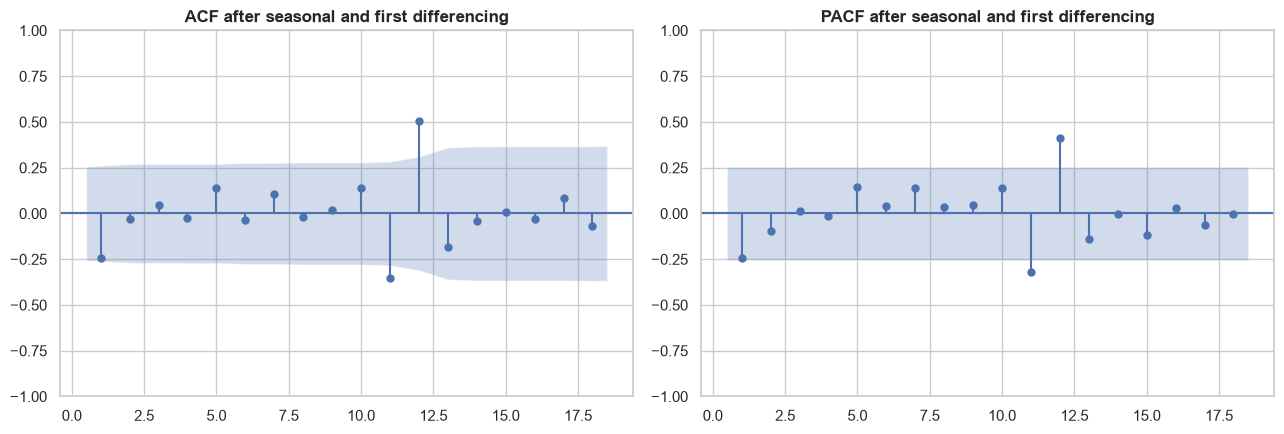

In [18]:
diagnostic_series = seasonal_first_difference.dropna()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_acf(diagnostic_series, lags=18, zero=False, ax=axes[0])
plot_pacf(diagnostic_series, lags=18, zero=False, method="ywm", ax=axes[1])
axes[0].set_title("ACF after seasonal and first differencing")
axes[1].set_title("PACF after seasonal and first differencing")
fig.tight_layout()
plt.show()

### Chronological evaluation design

- **Training:** first 60 months (1993-1997)
- **Test:** final 12 months (1998)
- **Naive baselines:** last observed value and the value from the same month one year earlier
- **Statistical model:** SARIMA(1,1,1)(1,1,0,12), chosen as a compact demonstration consistent with trend and annual seasonality
- **Metrics:** MAE and RMSE in transaction-count units

This is a single predeclared specification, not an exhaustive parameter search. With only 72 observations, extensive tuning would create unstable model-selection claims.

In [19]:
TEST_MONTHS = 12
train = activity_series.iloc[:-TEST_MONTHS]
test = activity_series.iloc[-TEST_MONTHS:]

last_value_naive = pd.Series(train.iloc[-1], index=test.index, name="last_value_naive")
seasonal_naive = activity_series.shift(12).loc[test.index].rename("seasonal_naive")

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    warnings.simplefilter("ignore", DeprecationWarning)
    sarima_model = SARIMAX(
        train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 0, 12),
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

sarima_result = sarima_model.get_forecast(steps=TEST_MONTHS)
sarima_forecast = sarima_result.predicted_mean.rename("sarima")
sarima_interval = sarima_result.conf_int(alpha=0.05)
residual_adf_p_value = adfuller(sarima_model.resid.iloc[14:], autolag="AIC")[1]

split_summary = pd.Series(
    {
        "training start": train.index.min().date(),
        "training end": train.index.max().date(),
        "test start": test.index.min().date(),
        "test end": test.index.max().date(),
        "training observations": len(train),
        "test observations": len(test),
        "SARIMA AIC": sarima_model.aic,
        "SARIMA BIC": sarima_model.bic,
        "SARIMA residual ADF p-value": residual_adf_p_value,
    },
    name="value",
)
display(split_summary.to_frame())

,value
training start,1993-01-01
training end,1997-12-01
test start,1998-01-01
test end,1998-12-01
training observations,60
test observations,12
SARIMA AIC,556.671439
SARIMA BIC,562.776881
SARIMA residual ADF p-value,0.0


,model,MAE,RMSE
0,SARIMA,2321.204834,3178.276490
1,Last-value naive,3857.750000,5145.290606
2,Seasonal naive,3941.666667,4494.930719


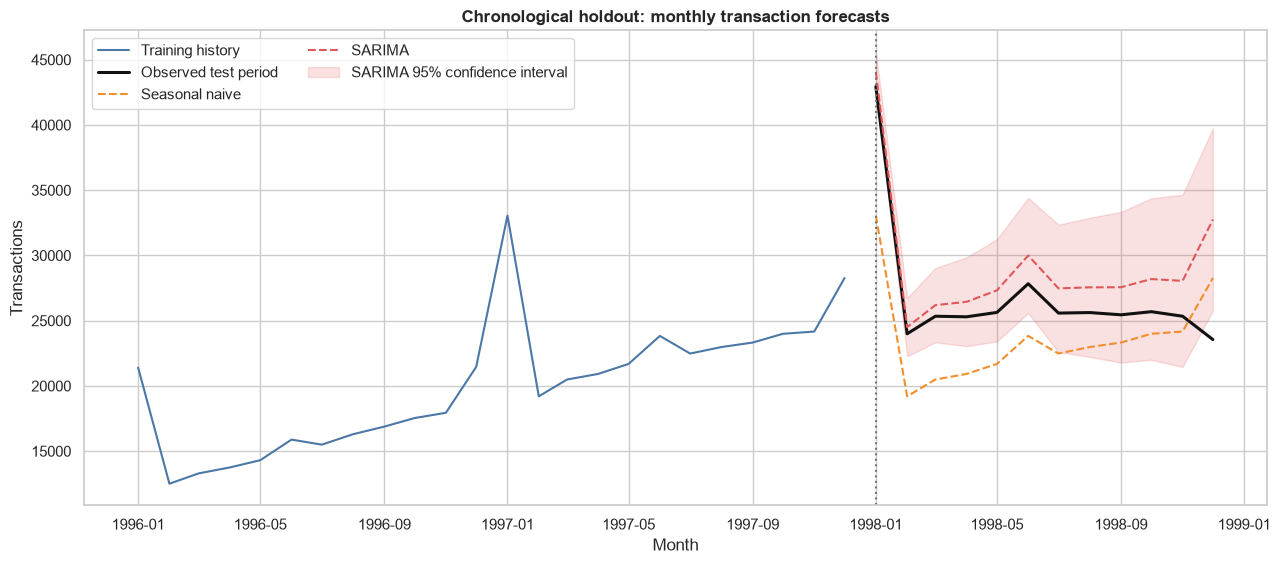

Lowest holdout MAE: SARIMA (2,321 transactions; RMSE 3,178).


In [20]:
forecast_candidates = {
    "Last-value naive": last_value_naive,
    "Seasonal naive": seasonal_naive,
    "SARIMA": sarima_forecast,
}
forecast_evaluation = pd.DataFrame(
    [
        {
            "model": name,
            "MAE": mean_absolute_error(test, prediction),
            "RMSE": root_mean_squared_error(test, prediction),
        }
        for name, prediction in forecast_candidates.items()
    ]
).sort_values("MAE").reset_index(drop=True)
display(forecast_evaluation)

fig, ax = plt.subplots(figsize=(13, 5.8))
ax.plot(train.index[-24:], train.iloc[-24:], label="Training history", color="#4C78A8")
ax.plot(test, label="Observed test period", color="#111111", linewidth=2.2)
ax.plot(seasonal_naive, label="Seasonal naive", color="#F28E2B", linestyle="--")
ax.plot(sarima_forecast, label="SARIMA", color="#E15759", linestyle="--")
ax.fill_between(
    test.index,
    sarima_interval.iloc[:, 0].to_numpy(),
    sarima_interval.iloc[:, 1].to_numpy(),
    color="#E15759",
    alpha=0.18,
    label="SARIMA 95% confidence interval",
)
ax.axvline(test.index.min(), color="#777777", linestyle=":", linewidth=1.5)
ax.set(title="Chronological holdout: monthly transaction forecasts", xlabel="Month", ylabel="Transactions")
ax.legend(ncol=2)
fig.tight_layout()
plt.show()

best_forecast = forecast_evaluation.iloc[0]
print(
    f"Lowest holdout MAE: {best_forecast['model']} "
    f"({best_forecast['MAE']:,.0f} transactions; RMSE {best_forecast['RMSE']:,.0f})."
)

### Forecast interpretation limits

- Confidence intervals describe parameter and residual uncertainty **conditional on the fitted model**; they do not cover every structural change.
- Portfolio growth is a major driver of aggregate counts, so the series is not a pure measure of changing customer behavior.
- January activity is visibly different from other months and may reflect recurring banking processes as well as customer behavior.
- The 12-month holdout provides one evaluation window. It is adequate for a course demonstration but insufficient for production model selection.
- Forecasting each account separately would create thousands of sparse, unstable models and is outside this project's scope.

## 6. Week 7 — Recommendation Systems through Association Rules

Berka contains no ratings, clicks, product catalogue, or response-to-recommendation outcomes. Collaborative filtering would therefore manufacture a preference signal that the dataset does not contain. A more defensible course connection is to treat each account as a basket of observed service and payment attributes.

The resulting rules answer: **when attributes A and B are observed, how often is attribute C also observed, and is that co-occurrence greater than expected from C's prevalence?** They do not establish suitability, causation, customer interest, or incremental business value.

,support,accounts
uses_standing_orders,0.835111,3758
pays_household_expenses,0.765111,3443
has_card,0.198222,892
receives_pension,0.164444,740
has_loan,0.151556,682
pays_insurance,0.118444,533
receives_salary_like_deposit,0.095333,429
makes_leasing_payments,0.075778,341


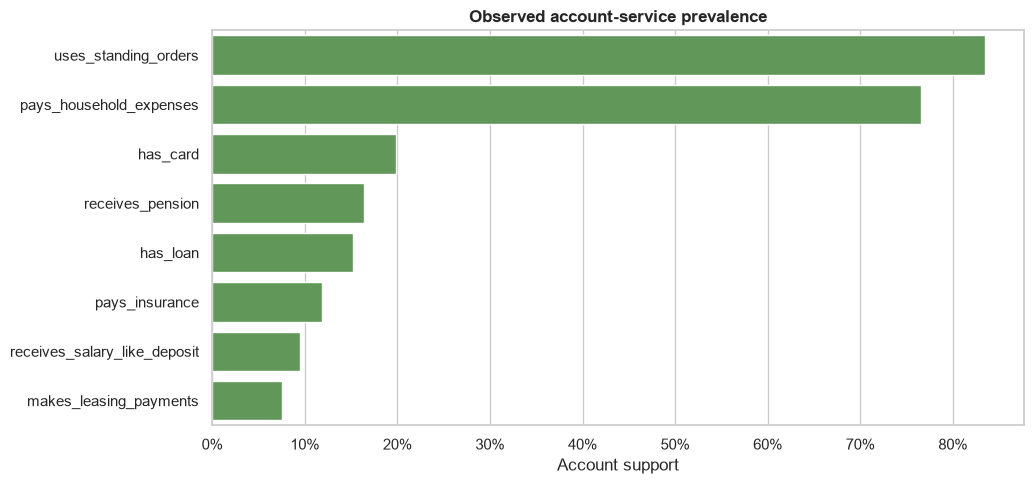

In [21]:
service_columns = {
    "has_card": "has_card",
    "has_loan": "has_loan",
    "has_standing_order": "uses_standing_orders",
    "receives_salary_like_deposit": "receives_salary_like_deposit",
    "receives_pension": "receives_pension",
    "pays_household_expenses": "pays_household_expenses",
    "pays_insurance": "pays_insurance",
    "makes_leasing_payments": "makes_leasing_payments",
}
service_matrix = customer_features[list(service_columns)].rename(columns=service_columns).astype(bool)

service_prevalence = (
    service_matrix.mean()
    .sort_values(ascending=False)
    .rename("support")
    .to_frame()
    .assign(accounts=lambda frame: (frame["support"] * len(service_matrix)).round().astype(int))
)
display(service_prevalence)

fig, ax = plt.subplots(figsize=(10.5, 5))
sns.barplot(
    data=service_prevalence.reset_index().rename(columns={"index": "service"}),
    y="service",
    x="support",
    color="#59A14F",
    ax=ax,
)
ax.set(title="Observed account-service prevalence", xlabel="Account support", ylabel="")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
fig.tight_layout()
plt.show()

In [22]:
MIN_SUPPORT = 0.03
MIN_CONFIDENCE = 0.35
MIN_LIFT = 1.05

frequent_itemsets = apriori(
    service_matrix,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=3,
)
frequent_itemsets["item_count"] = frequent_itemsets["itemsets"].map(len)
frequent_itemsets = frequent_itemsets.sort_values(["item_count", "support"], ascending=[True, False])
display(frequent_itemsets.head(20))

all_rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=MIN_CONFIDENCE,
)
all_rules["antecedent_count"] = all_rules["antecedents"].map(len)
all_rules["consequent_count"] = all_rules["consequents"].map(len)

standing_order_linked_services = {
    "has_loan",
    "pays_household_expenses",
    "pays_insurance",
    "makes_leasing_payments",
}


def is_structural_standing_order_rule(row: pd.Series) -> bool:
    rule_items = set(row["antecedents"]) | set(row["consequents"])
    return "uses_standing_orders" in rule_items and bool(rule_items & standing_order_linked_services)


candidate_rules = all_rules.loc[
    (all_rules["support"] >= MIN_SUPPORT)
    & (all_rules["confidence"] >= MIN_CONFIDENCE)
    & (all_rules["lift"] >= MIN_LIFT)
    & (all_rules["consequent_count"] == 1)
].copy()
candidate_rules["structural_standing_order_rule"] = candidate_rules.apply(
    is_structural_standing_order_rule,
    axis=1,
)
candidate_rules = candidate_rules.loc[~candidate_rules["structural_standing_order_rule"]].copy()
candidate_rules = candidate_rules.sort_values(["lift", "confidence", "support"], ascending=False)

display(
    candidate_rules[
        ["antecedents", "consequents", "support", "confidence", "lift", "leverage", "conviction"]
    ].head(15)
)

,support,itemsets,item_count
2,0.835111,frozenset({uses_standing_orders}),1
5,0.765111,frozenset({pays_household_expenses}),1
0,0.198222,frozenset({has_card}),1
4,0.164444,frozenset({receives_pension}),1
1,0.151556,frozenset({has_loan}),1
6,0.118444,frozenset({pays_insurance}),1
3,0.095333,frozenset({receives_salary_like_deposit}),1
7,0.075778,frozenset({makes_leasing_payments}),1
17,0.754000,"frozenset({uses_standing_orders, pays_househol...",2
21,0.164444,"frozenset({receives_pension, pays_household_ex...",2


,antecedents,consequents,support,confidence,lift,leverage,conviction
38,"frozenset({receives_salary_like_deposit, pays_...",frozenset({has_loan}),0.030667,0.545455,3.599040,0.022146,1.866578
13,frozenset({receives_salary_like_deposit}),frozenset({has_loan}),0.046667,0.489510,3.229908,0.032218,1.662021
2,frozenset({receives_pension}),frozenset({pays_household_expenses}),0.164444,1.000000,1.307000,0.038626,inf
7,frozenset({pays_insurance}),frozenset({pays_household_expenses}),0.118444,1.000000,1.307000,0.027821,inf
3,frozenset({receives_pension}),frozenset({uses_standing_orders}),0.163556,0.994595,1.190973,0.026226,30.504444


,rule,antecedents,consequents,antecedent_count,consequent_count,antecedent_support,consequent_support,support,confidence,lift,leverage,conviction
0,pays_household_expenses | receives_salary_like...,pays_household_expenses | receives_salary_like...,has_loan,2,1,0.056222,0.151556,0.030667,0.545455,3.599040,0.022146,1.866578
1,receives_salary_like_deposit -> has_loan,receives_salary_like_deposit,has_loan,1,1,0.095333,0.151556,0.046667,0.489510,3.229908,0.032218,1.662021
2,receives_pension -> pays_household_expenses,receives_pension,pays_household_expenses,1,1,0.164444,0.765111,0.164444,1.000000,1.307000,0.038626,inf
3,pays_insurance -> pays_household_expenses,pays_insurance,pays_household_expenses,1,1,0.118444,0.765111,0.118444,1.000000,1.307000,0.027821,inf
4,receives_pension -> uses_standing_orders,receives_pension,uses_standing_orders,1,1,0.164444,0.835111,0.163556,0.994595,1.190973,0.026226,30.504444


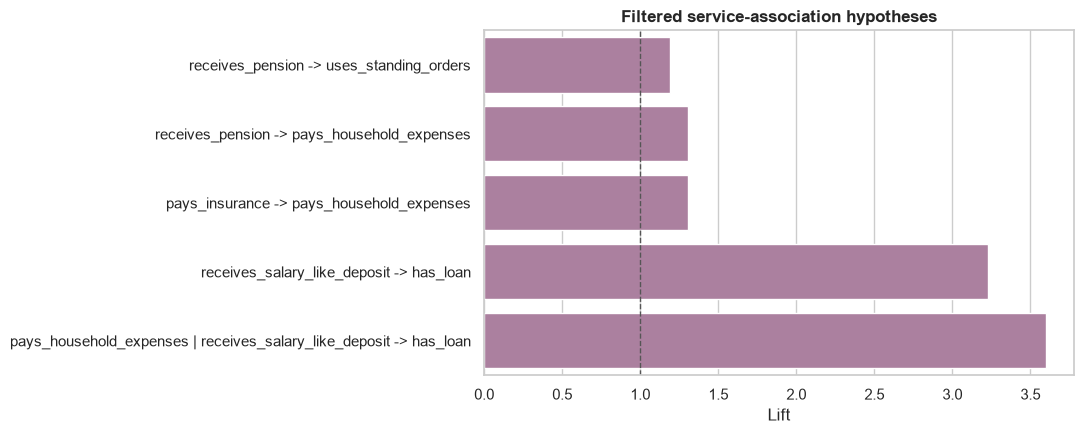

In [23]:
association_rules_output = candidate_rules.copy()
association_rules_output["antecedents"] = association_rules_output["antecedents"].map(
    lambda items: " | ".join(sorted(items))
)
association_rules_output["consequents"] = association_rules_output["consequents"].map(
    lambda items: " | ".join(sorted(items))
)
association_rules_output["rule"] = (
    association_rules_output["antecedents"] + " -> " + association_rules_output["consequents"]
)
association_rules_output = association_rules_output.rename(
    columns={
        "antecedent support": "antecedent_support",
        "consequent support": "consequent_support",
    }
)
rule_output_columns = [
    "rule",
    "antecedents",
    "consequents",
    "antecedent_count",
    "consequent_count",
    "antecedent_support",
    "consequent_support",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction",
]
association_rules_output = association_rules_output[rule_output_columns].reset_index(drop=True)

assert not association_rules_output.empty, "No recommendation hypotheses met the declared thresholds."
assert (association_rules_output["support"] >= MIN_SUPPORT).all()
assert (association_rules_output["confidence"] >= MIN_CONFIDENCE).all()
assert (association_rules_output["lift"] >= MIN_LIFT).all()

display(association_rules_output.head(15))

top_rules = association_rules_output.head(12).sort_values("lift")
fig, ax = plt.subplots(figsize=(11, max(4.5, 0.45 * len(top_rules))))
sns.barplot(data=top_rules, y="rule", x="lift", color="#B279A2", ax=ax)
ax.axvline(1, color="#555555", linestyle="--", linewidth=1)
ax.set(title="Filtered service-association hypotheses", xlabel="Lift", ylabel="")
fig.tight_layout()
plt.show()

### How to read the rules

- **Support:** proportion of all accounts containing the complete itemset.
- **Confidence:** among accounts with the antecedent, proportion also containing the consequent.
- **Lift:** observed co-occurrence divided by expected co-occurrence under independence; values above 1 indicate positive association.
- **Filtering:** retained rules have support at least 3%, confidence at least 35%, lift at least 1.05, and one consequent.
- **Structural safeguards:** rules connecting standing orders to services defined from standing-order records or loan repayment setup are removed because they partly restate the data construction.
- **Credit safeguard:** loan-related associations are descriptive context only. They must not be used to approve, market, or recommend credit without suitability, fairness, and outcome evidence that Berka does not provide.

A surviving rule is a candidate for further investigation—for example, a future controlled study of service relevance—not permission to target an individual account.

## 7. Persist and validate Gold outputs

| Output | Grain | Downstream purpose |
|---|---|---|
| `customer_behavior_features.parquet` | One row per account | Notebook 3 segmentation and profiling |
| `monthly_banking_activity.parquet` | One row per calendar month | Temporal reporting and forecast reproduction |
| `service_association_rules.parquet` | One row per filtered directional rule | Recommendation-hypothesis review |

In [24]:
outputs = {
    "customer_behavior_features.parquet": customer_features,
    "monthly_banking_activity.parquet": monthly_activity,
    "service_association_rules.parquet": association_rules_output,
}

for index, (filename, frame) in enumerate(outputs.items()):
    relation_name = f"notebook_output_{index}"
    output_path = PROCESSED_DIR / filename
    connection.register(relation_name, frame)
    connection.execute(
        "COPY (SELECT * FROM "
        + relation_name
        + ") TO "
        + sql_literal(output_path)
        + " (FORMAT PARQUET, COMPRESSION ZSTD)"
    )
    connection.unregister(relation_name)

output_validation_rows = []
for filename, frame in outputs.items():
    output_path = PROCESSED_DIR / filename
    stored_rows = connection.execute(
        "SELECT COUNT(*) FROM read_parquet(" + sql_literal(output_path) + ")"
    ).fetchone()[0]
    output_validation_rows.append(
        {
            "output": filename,
            "path": str(output_path.relative_to(PROJECT_ROOT)),
            "expected_rows": len(frame),
            "stored_rows": stored_rows,
            "columns": len(frame.columns),
            "size_kb": round(output_path.stat().st_size / 1024, 1),
            "valid": stored_rows == len(frame),
        }
    )

output_validation = pd.DataFrame(output_validation_rows)
display(output_validation)
assert output_validation["valid"].all()

,output,path,expected_rows,stored_rows,columns,size_kb,valid
0,customer_behavior_features.parquet,data/processed/customer_behavior_features.parquet,4500,4500,39,377.4,True
1,monthly_banking_activity.parquet,data/processed/monthly_banking_activity.parquet,72,72,13,6.6,True
2,service_association_rules.parquet,data/processed/service_association_rules.parquet,5,5,12,2.6,True


## 8. Findings and handoff

- The observed portfolio grows from 96 active accounts in January 1993 to roughly 4,480 in most of 1998, so totals must be interpreted alongside exposure-adjusted behavior.
- January has the highest average withdrawal frequency (4.76 withdrawals per active account); December is a distant second (2.60). This supports an annual-pattern hypothesis without identifying its cause.
- Transaction value, activity intensity, funding channel, balance behavior, and service breadth provide distinct candidate dimensions for segmentation. Exactly 429 accounts meet the documented salary-like heuristic, which remains unverified.
- Valid negative balances and extreme transaction values remain behavioral observations, not evidence of error or fraud.
- Monthly transaction activity contains trend and annual seasonality. The ADF tests do not reject non-stationarity for the displayed transformations, although the fitted SARIMA residuals do; the short history and changing portfolio still limit forecast certainty.
- SARIMA has the lowest 1998 holdout error in this declared comparison (MAE 2,321 transactions versus 3,858 for last-value naive and 3,942 for seasonal naive).
- Service rules identify positive co-occurrence patterns only. They are recommendation hypotheses, not personalized recommendations or proof of unmet need.
- Demographics and loan outcomes remain outside the clustering feature set and can be used later only for responsible post-hoc validation.

**Next notebook:** `03_customer_segmentation.ipynb` will select and transform defensible behavioral features, compare clustering solutions, evaluate stability and separation, profile the resulting segments, and analyze contextual outliers without fraud labels.